<a href="https://www.kaggle.com/code/shreeyashah/digit-recognizer-using-cnn?scriptVersionId=316764808" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [21]:
import pandas as pd
import numpy as np
import tensorflow
from tensorflow.keras import Sequential, layers
from tensorflow.keras.layers import Dense, Conv2D, AveragePooling2D, Flatten

In [11]:
df_train = pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")
df_test = pd.read_csv("/kaggle/input/competitions/digit-recognizer/test.csv")

In [13]:
df_train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [53]:
X_test = df_test.iloc[:, :].values

In [54]:
X_train = df_train.iloc[:, 1:].values
y_train = df_train.iloc[:, 0].values

In [55]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_tnf = sc.fit_transform(X_train)
X_test_tnf = sc.transform(X_test)

In [56]:
X_train_tnf = X_train_tnf.reshape(-1, 28, 28, 1)
X_test_tnf = X_test.reshape(-1, 28, 28, 1)

In [85]:
model = Sequential()
model.add(Conv2D(6, kernel_size = (5,5), padding = 'valid', activation = 'relu', input_shape=(28,28,1)))
model.add(AveragePooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))
model.add(Conv2D(16, kernel_size = (5,5), padding = 'valid', activation = 'relu'))
model.add(AveragePooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))
model.add(Flatten())
model.add(Dense(120,activation='relu'))
model.add(Dense(84, activation = 'relu'))
model.add(Dense(10, activation = 'softmax'))

In [86]:
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_16            │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_17            │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [87]:
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [88]:
history = model.fit(X_train_tnf, y_train, epochs = 20, validation_split = 0.2, batch_size = 8)

Epoch 1/20
4200/4200 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - accuracy: 0.8799 - loss: 0.3652 - val_accuracy: 0.9764 - val_loss: 0.0746
Epoch 2/20
4200/4200 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.9774 - loss: 0.0710 - val_accuracy: 0.9815 - val_loss: 0.0584
Epoch 3/20
4200/4200 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.9849 - loss: 0.0501 - val_accuracy: 0.9849 - val_loss: 0.0512
Epoch 4/20
4200/4200 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.9885 - loss: 0.0379 - val_accuracy: 0.9829 - val_loss: 0.0629
Epoch 5/20
4200/4200 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.9910 - loss: 0.0303 - val_accuracy: 0.9868 - val_loss: 0.0486
Epoch 6/20
4200/4200 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.9920 - loss: 0.0252 - val_accuracy: 0.9873 - val_loss: 0.0476
Epoch 7/20
4200/4200 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.9944 - loss: 0.0179 - val_accuracy: 0.9881 - val_loss: 0.0472
Epoch 8/20
4200/4200 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9934 - loss: 0

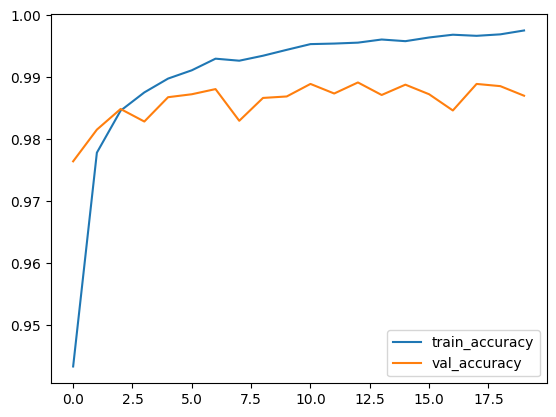

In [89]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label = 'train_accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.legend()

In [90]:
y_pred_prob = model.predict(X_test_tnf)

875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [91]:
y_pred = np.argmax(y_pred_prob, axis = 1)
y_pred

array([2, 0, 9, ..., 3, 9, 2])

In [92]:
id = np.array(range(1,len(y_pred)+1))
id

array([    1,     2,     3, ..., 27998, 27999, 28000])

In [93]:
results = pd.DataFrame({'ImageId':id,'Label':y_pred})
results.to_csv('submission.csv', index=False)